In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from path_config import PathConfig
paths = PathConfig()

In [2]:
dl_data = pd.read_excel(paths.dl_path, sheet_name='Series Formatted Data')
ul_data = pd.read_excel(paths.ul_path, sheet_name='Series Formatted Data')


In [3]:
dl_data.iloc[50661].to_dict()

{'Message': 50661,
 'Time': Timestamp('2025-03-14 12:26:03.298000'),
 'Longitude': 29.01915,
 'Latitude': 41.10753,
 'Technology_Mode': '5GSA',
 'NR_UE_PCI_0': 23.0,
 'NR_UE_RSRP_0': -126.5,
 'NR_UE_RSRQ_0': -23.2,
 'NR_UE_SINR_0': -12.6,
 'NR_UE_Nbr_PCI_0': 13.0,
 'NR_UE_Nbr_PCI_1': 30.0,
 'NR_UE_Nbr_PCI_2': 40.0,
 'NR_UE_Nbr_PCI_3': 68.0,
 'NR_UE_Nbr_PCI_4': 76.0,
 'NR_UE_Nbr_RSRP_0': -121.5,
 'NR_UE_Nbr_RSRP_1': -120.8,
 'NR_UE_Nbr_RSRP_2': -118.1,
 'NR_UE_Nbr_RSRP_3': -119.5,
 'NR_UE_Nbr_RSRP_4': -116.8,
 'NR_UE_Nbr_RSRQ_0': -19.8,
 'NR_UE_Nbr_RSRQ_1': -17.9,
 'NR_UE_Nbr_RSRQ_2': -16.6,
 'NR_UE_Nbr_RSRQ_3': -17.6,
 'NR_UE_Nbr_RSRQ_4': -15.8,
 'NR_UE_Timing_Advance': nan,
 'NR_UE_Pathloss_DL_0': nan,
 'NR_UE_Throughput_PDCP_DL': nan,
 'App_Throughput_DL': nan,
 'NR_UE_NACK_Rate_DL_0': nan,
 'NR_UE_Ack_As_Nack_DL_0': nan,
 'NR_UE_MCS_DL_0': nan,
 'NR_UE_RB_Num_DL_0': nan,
 'NR_UE_Modulation_Avg_DL_0': nan,
 'NR_UE_RI_DL_0': nan,
 'NR_UE_BLER_DL_0': nan,
 'NR_UE_CCE_AggregationLev_0':

In [4]:
dl_data[dl_data[[col for col in dl_data.columns if 'RSRP' in col]].notna().all(axis=1)].to_dict()

{'Message': {50661: 50661, 51653: 51653},
 'Time': {50661: Timestamp('2025-03-14 12:26:03.298000'),
  51653: Timestamp('2025-03-14 12:26:15.841000')},
 'Longitude': {50661: 29.01915, 51653: 29.0186},
 'Latitude': {50661: 41.10753, 51653: 41.10735},
 'Technology_Mode': {50661: '5GSA', 51653: '5GSA'},
 'NR_UE_PCI_0': {50661: 23.0, 51653: 30.0},
 'NR_UE_RSRP_0': {50661: -126.5, 51653: -131.5},
 'NR_UE_RSRQ_0': {50661: -23.2, 51653: -23.5},
 'NR_UE_SINR_0': {50661: -12.6, 51653: -16.0},
 'NR_UE_Nbr_PCI_0': {50661: 13.0, 51653: 13.0},
 'NR_UE_Nbr_PCI_1': {50661: 30.0, 51653: 23.0},
 'NR_UE_Nbr_PCI_2': {50661: 40.0, 51653: 40.0},
 'NR_UE_Nbr_PCI_3': {50661: 68.0, 51653: 68.0},
 'NR_UE_Nbr_PCI_4': {50661: 76.0, 51653: 76.0},
 'NR_UE_Nbr_RSRP_0': {50661: -121.5, 51653: -121.0},
 'NR_UE_Nbr_RSRP_1': {50661: -120.8, 51653: -123.0},
 'NR_UE_Nbr_RSRP_2': {50661: -118.1, 51653: -124.0},
 'NR_UE_Nbr_RSRP_3': {50661: -119.5, 51653: -122.7},
 'NR_UE_Nbr_RSRP_4': {50661: -116.8, 51653: -123.5},
 'NR_UE

In [5]:

bs_data = pd.read_excel(paths.Hucre_Bilgileri)
grouped_dl = pd.read_csv(paths._processed_saha_olcum_dir / 'grouped_dl.csv')
grouped_ul = pd.read_csv(paths._processed_saha_olcum_dir / 'grouped_ul.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\osman\\OneDrive - Harran Üniversitesi\\teknofest\\5G-Positioning-Competition\\Data\\Processed\\DL_UL_Scanner\\grouped_dl.csv'

In [ ]:

dl_data = dl_data.drop(["Technology_Mode"],axis=1)
dl_data = dl_data.loc[:, ~dl_data.columns.str.contains('^Unnamed')]

ul_data = ul_data.drop(["Technology_Mode"],axis=1)
ul_data = ul_data.loc[:, ~ul_data.columns.str.contains('^Unnamed')]


In [ ]:
dl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72480 entries, 0 to 72479
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Message                      72480 non-null  int64         
 1   Time                         72480 non-null  datetime64[ns]
 2   Longitude                    72478 non-null  float64       
 3   Latitude                     72478 non-null  float64       
 4   NR_UE_PCI_0                  2471 non-null   float64       
 5   NR_UE_RSRP_0                 1943 non-null   float64       
 6   NR_UE_RSRQ_0                 1943 non-null   float64       
 7   NR_UE_SINR_0                 1933 non-null   float64       
 8   NR_UE_Nbr_PCI_0              1414 non-null   float64       
 9   NR_UE_Nbr_PCI_1              504 non-null    float64       
 10  NR_UE_Nbr_PCI_2              127 non-null    float64       
 11  NR_UE_Nbr_PCI_3              24 non-null 

In [ ]:
def plot_signals(df, signal_type, col):
    plt.figure(figsize=(20, 5))
    plt.title(f'{signal_type} Values For {col}')
    plt.xlabel('Zaman')
    plt.ylabel(signal_type)

    unique_pcis = df[col].unique()

    for pci in unique_pcis:
        pci_data = df[df[col] == pci].copy()

        # Ardışık olmayan noktaları tespit et (örneğin 100'den büyük zaman farkı kopma sayılabilir)
        pci_data['group'] = (pci_data['Message'].diff() > 400).cumsum()

        for _, group_data in pci_data.groupby('group'):
            plt.plot(group_data["Message"], group_data[col.replace("PCI", signal_type)], label=f'PCI {pci}' if _ == 0 else "", linewidth=1)

    plt.legend()
    plt.show()

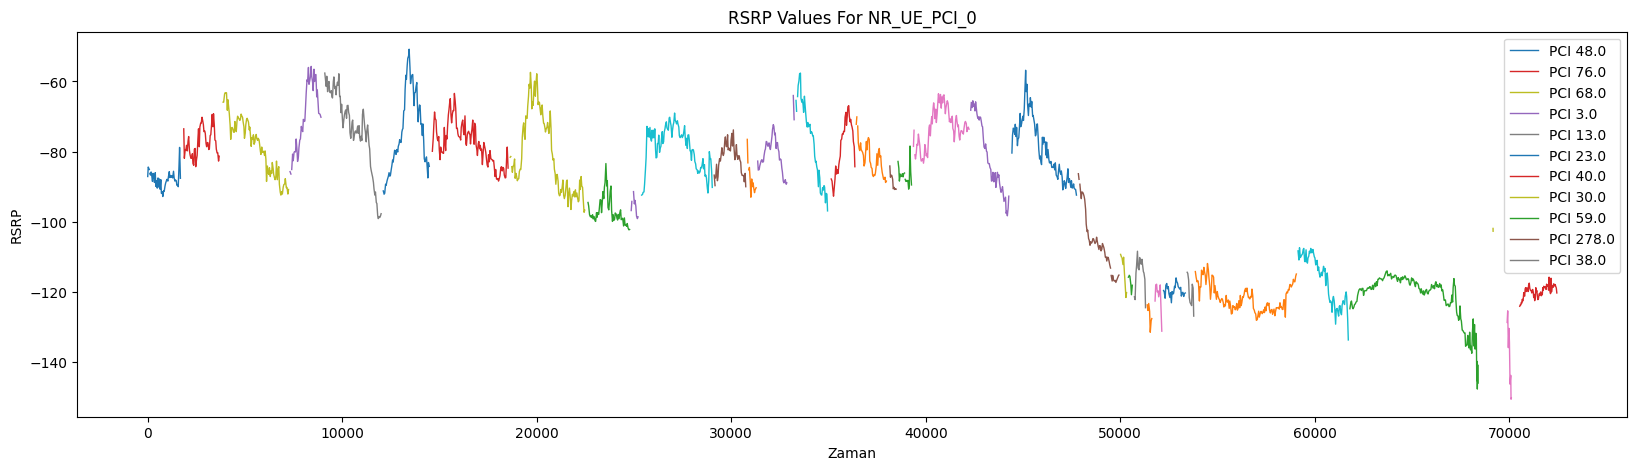

In [ ]:
plot_signals(dl_data, "RSRP", "NR_UE_PCI_0")

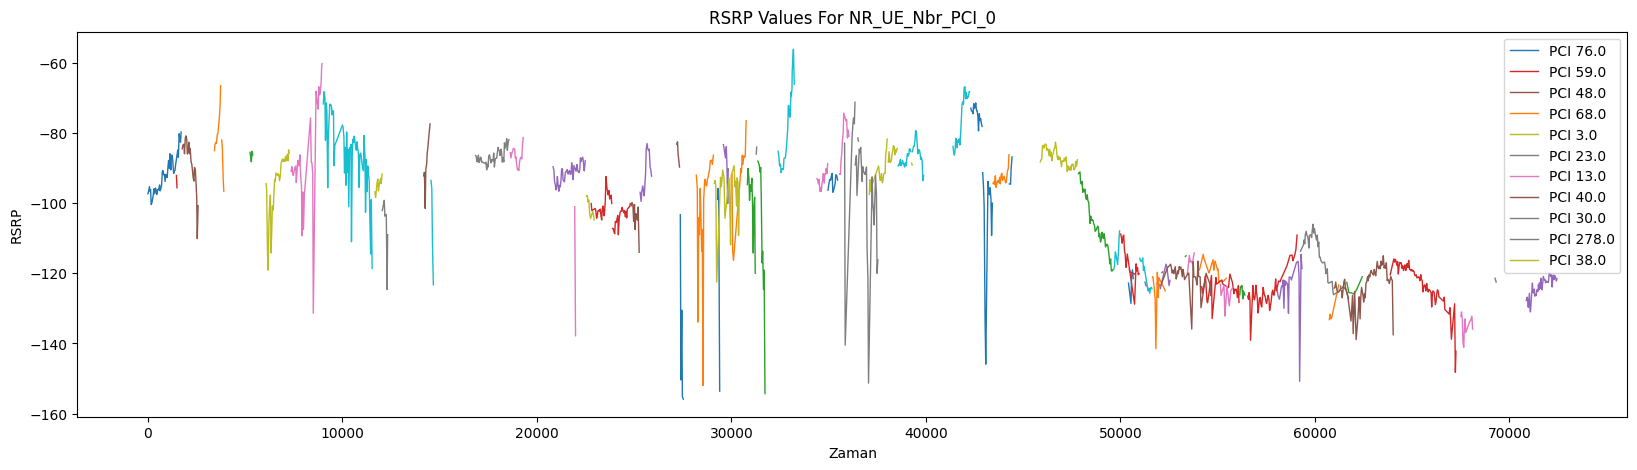

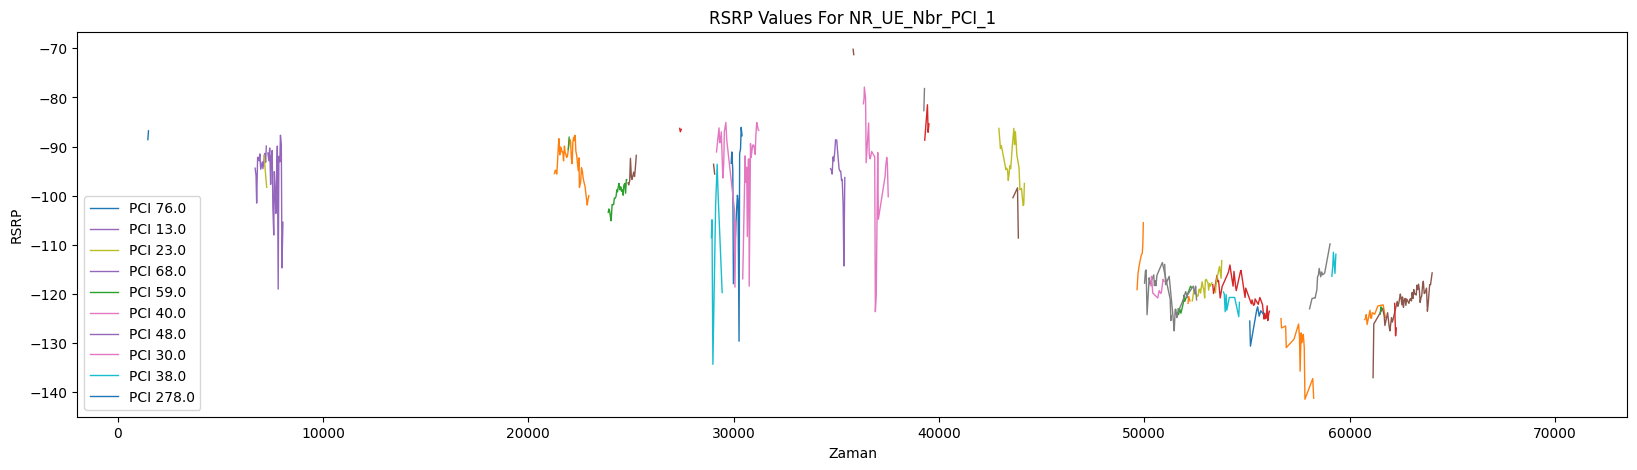

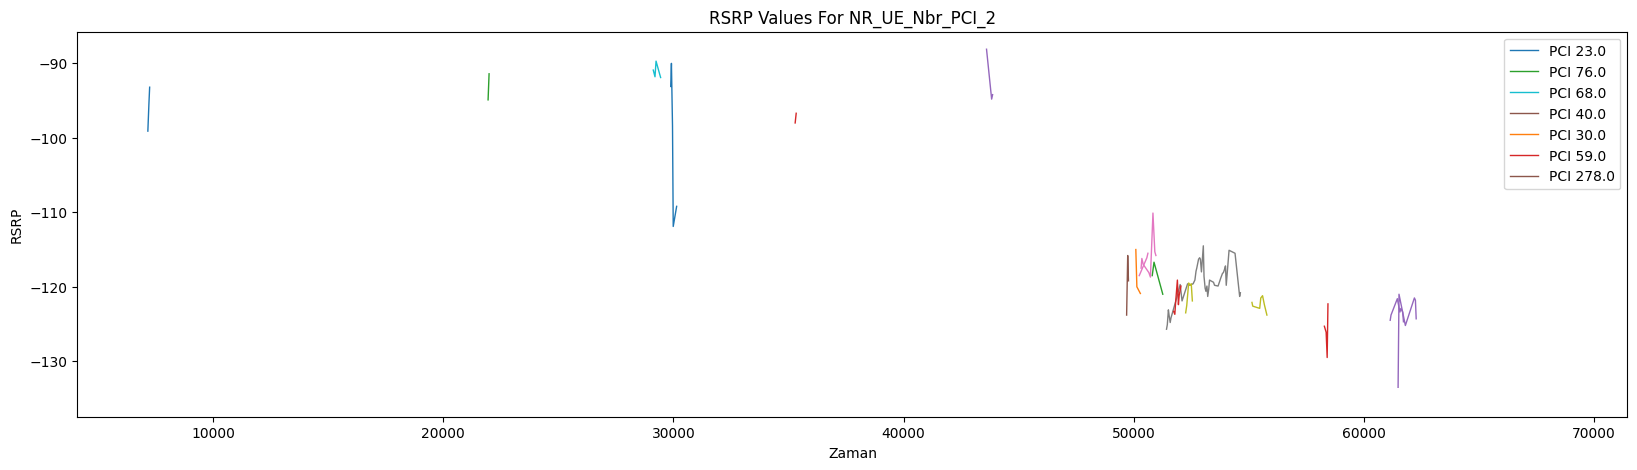

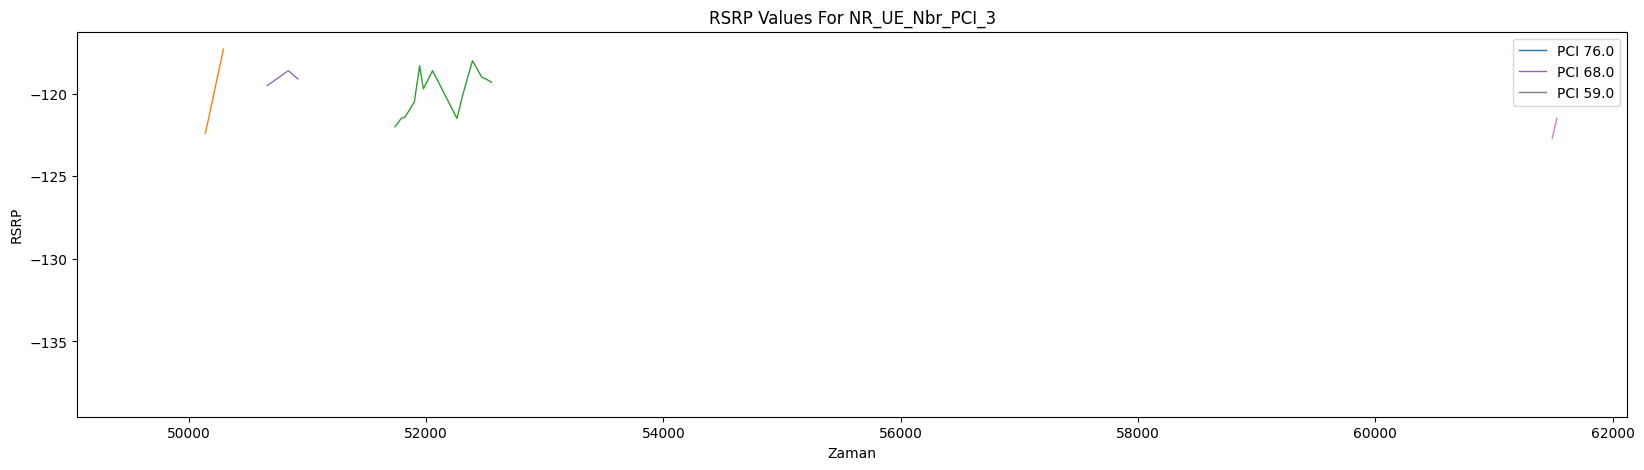

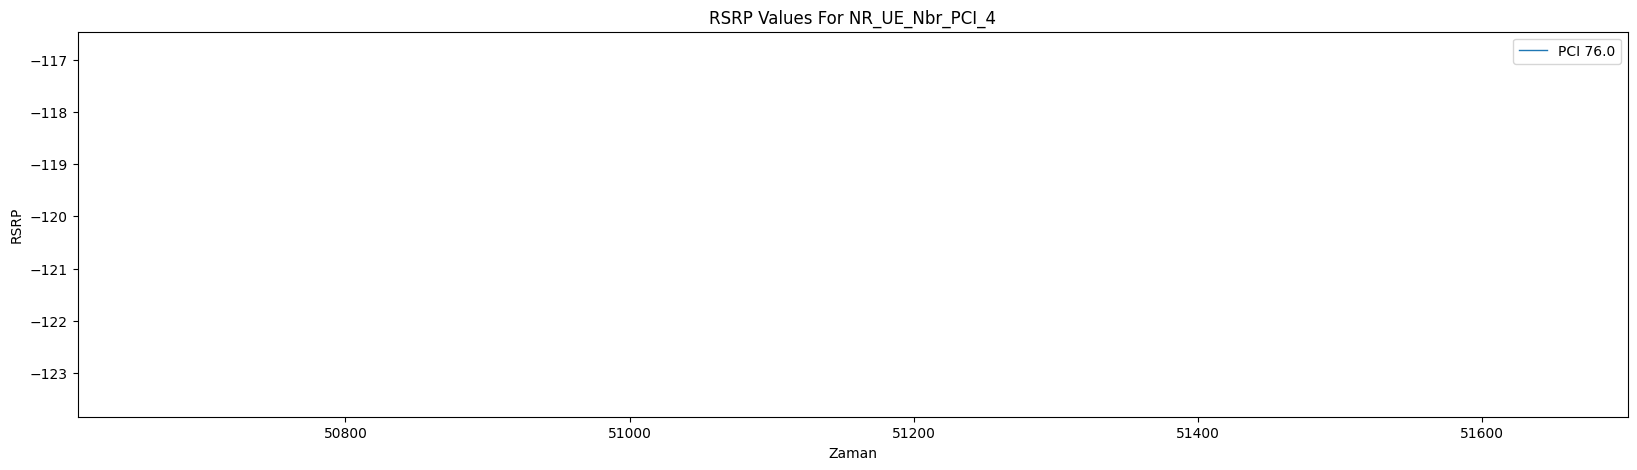

In [ ]:
plot_signals(dl_data, "RSRP", "NR_UE_Nbr_PCI_0")
plot_signals(dl_data, "RSRP", "NR_UE_Nbr_PCI_1")
plot_signals(dl_data, "RSRP", "NR_UE_Nbr_PCI_2")
plot_signals(dl_data, "RSRP", "NR_UE_Nbr_PCI_3")
plot_signals(dl_data, "RSRP", "NR_UE_Nbr_PCI_4")

In [ ]:
dl_data.isna().sum().sort_values()

Message                            0
Time                               0
NR_UE_RRCReEstFail                 0
NR_UE_RRCConnectionAttempt         0
NR_UE_RRCConnectionComplete        0
NR_UE_RRCConnectionDrop            0
NR_UE_RRCHOOK                      0
NR_UE_RRCHOAttempt                 0
NR_UE_RACH_Fail                    0
NR_UE_RRCReEstAttempt              0
NR_UE_RACH_OK                      0
NR_UE_RACH_Attempt                 0
NR_UE_RRCConnectionSetupOk         0
Longitude                          2
Latitude                           2
NR_UE_RI_DL_0                  68658
NR_UE_PCI_0                    70009
NR_UE_Throughput_PDCP_DL       70486
NR_UE_NACK_Rate_UL_0           70531
NR_UE_RSRQ_0                   70537
NR_UE_RSRP_0                   70537
NR_UE_Pathloss_DL_0            70539
NR_UE_Power_Tx_PUSCH_0         70539
NR_UE_BLER_DL_0                70546
NR_UE_RB_Num_DL_0              70546
NR_UE_Ack_As_Nack_DL_0         70546
NR_UE_NACK_Rate_DL_0           70546
N

In [ ]:
print(  dl_data[["NR_UE_PCI_0", "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0"]].dropna(how="all").isna().sum(),
        dl_data[["NR_UE_Nbr_PCI_0", "NR_UE_Nbr_RSRP_0", "NR_UE_Nbr_RSRQ_0"]].dropna(how="all").isna().sum(),
        dl_data[["NR_UE_Nbr_PCI_1", "NR_UE_Nbr_RSRP_1", "NR_UE_Nbr_RSRQ_1"]].dropna(how="all").isna().sum(),
        dl_data[["NR_UE_Nbr_PCI_2", "NR_UE_Nbr_RSRP_2", "NR_UE_Nbr_RSRQ_2"]].dropna(how="all").isna().sum(),
        dl_data[["NR_UE_Nbr_PCI_3", "NR_UE_Nbr_RSRP_3", "NR_UE_Nbr_RSRQ_3"]].dropna(how="all").isna().sum(),
        dl_data[["NR_UE_Nbr_PCI_4", "NR_UE_Nbr_RSRP_4", "NR_UE_Nbr_RSRQ_4"]].dropna(how="all").isna().sum(), sep="\n\n")

NR_UE_PCI_0       0
NR_UE_RSRP_0    528
NR_UE_RSRQ_0    528
NR_UE_SINR_0    538
dtype: int64

NR_UE_Nbr_PCI_0     0
NR_UE_Nbr_RSRP_0    0
NR_UE_Nbr_RSRQ_0    0
dtype: int64

NR_UE_Nbr_PCI_1     0
NR_UE_Nbr_RSRP_1    0
NR_UE_Nbr_RSRQ_1    0
dtype: int64

NR_UE_Nbr_PCI_2     0
NR_UE_Nbr_RSRP_2    0
NR_UE_Nbr_RSRQ_2    0
dtype: int64

NR_UE_Nbr_PCI_3     0
NR_UE_Nbr_RSRP_3    0
NR_UE_Nbr_RSRQ_3    0
dtype: int64

NR_UE_Nbr_PCI_4     0
NR_UE_Nbr_RSRP_4    0
NR_UE_Nbr_RSRQ_4    0
dtype: int64


In [ ]:
print(  ul_data[["NR_UE_PCI_0", "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0"]].dropna(how="all").isna().sum(),
        ul_data[["NR_UE_Nbr_PCI_0", "NR_UE_Nbr_RSRP_0", "NR_UE_Nbr_RSRQ_0"]].dropna(how="all").isna().sum(),
        ul_data[["NR_UE_Nbr_PCI_1", "NR_UE_Nbr_RSRP_1", "NR_UE_Nbr_RSRQ_1"]].dropna(how="all").isna().sum(),
        ul_data[["NR_UE_Nbr_PCI_2", "NR_UE_Nbr_RSRP_2", "NR_UE_Nbr_RSRQ_2"]].dropna(how="all").isna().sum(),
        ul_data[["NR_UE_Nbr_PCI_3", "NR_UE_Nbr_RSRP_3", "NR_UE_Nbr_RSRQ_3"]].dropna(how="all").isna().sum(),
        ul_data[["NR_UE_Nbr_PCI_4", "NR_UE_Nbr_RSRP_4", "NR_UE_Nbr_RSRQ_4"]].dropna(how="all").isna().sum(), sep="\n\n")

NR_UE_PCI_0       0
NR_UE_RSRP_0    581
NR_UE_RSRQ_0    581
NR_UE_SINR_0    619
dtype: int64

NR_UE_Nbr_PCI_0     0
NR_UE_Nbr_RSRP_0    0
NR_UE_Nbr_RSRQ_0    0
dtype: int64

NR_UE_Nbr_PCI_1     0
NR_UE_Nbr_RSRP_1    0
NR_UE_Nbr_RSRQ_1    0
dtype: int64

NR_UE_Nbr_PCI_2     0
NR_UE_Nbr_RSRP_2    0
NR_UE_Nbr_RSRQ_2    0
dtype: int64

NR_UE_Nbr_PCI_3     0
NR_UE_Nbr_RSRP_3    0
NR_UE_Nbr_RSRQ_3    0
dtype: int64

NR_UE_Nbr_PCI_4     0
NR_UE_Nbr_RSRP_4    0
NR_UE_Nbr_RSRQ_4    0
dtype: int64


bu arkadaşları interpolasyon ile dolduracağım

In [ ]:
def interpolate_signals(df, signal_columns):
    condition = ~df[signal_columns].isna().all(axis=1), signal_columns
    df.loc[condition] = df.loc[condition].interpolate(method='linear')

In [ ]:
signal_cols = ["NR_UE_PCI_0", "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0"]
interpolate_signals(dl_data, signal_cols)
interpolate_signals(ul_data, signal_cols)

In [ ]:
ul_data["NR_UE_PCI_0"].unique()

array([ nan,  48.,  76.,  68.,   3.,  13.,  23.,  40.,  30.,  59., 246.,
       278.,  38.])

In [ ]:
dl_data[dl_data["NR_UE_PCI_0"].isna() & dl_data[[col for col in dl_data.columns 
                                                 if "PCI" in col or "RSRP" in col or "RSRQ" in col or "SNIR" in col]].notna().any(axis=1)]

,Message,Time,Longitude,Latitude,NR_UE_PCI_0,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_PCI_0,NR_UE_Nbr_PCI_1,...,NR_UE_RRCReEst_EndResult,NR_UE_RRCConnectionAttempt,NR_UE_RRCConnectionSetupOk,NR_UE_RRCConnectionComplete,NR_UE_RRCConnectionDrop,NR_UE_RRCHOAttempt,NR_UE_RRCHOOK,NR_RRC_MsgType,NAS_5GS_MM_MessageType,NAS_5GS_SM_MessageType


In [ ]:
dl_data.dropna(subset=signal_cols, how='all')

,Message,Time,Longitude,Latitude,NR_UE_PCI_0,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_PCI_0,NR_UE_Nbr_PCI_1,...,NR_UE_RRCReEst_EndResult,NR_UE_RRCConnectionAttempt,NR_UE_RRCConnectionSetupOk,NR_UE_RRCConnectionComplete,NR_UE_RRCConnectionDrop,NR_UE_RRCHOAttempt,NR_UE_RRCHOOK,NR_RRC_MsgType,NAS_5GS_MM_MessageType,NAS_5GS_SM_MessageType
1,1,2025-03-14 12:14:33.444,NaN,NaN,48.0,-87.10,-11.20,7.300000,76.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
27,27,2025-03-14 12:14:34.030,29.02949,41.10723,48.0,-84.40,-11.00,6.900000,76.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
82,82,2025-03-14 12:14:34.331,29.02949,41.10723,48.0,-85.10,-11.20,6.466667,76.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
92,92,2025-03-14 12:14:34.331,29.02949,41.10723,48.0,-85.65,-11.35,6.033333,NaN,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
111,111,2025-03-14 12:14:34.501,29.02949,41.10723,48.0,-86.20,-11.50,5.600000,76.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72328,72328,2025-03-14 12:32:15.500,29.02143,41.10030,68.0,-118.30,-13.40,0.000000,59.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
72359,72359,2025-03-14 12:32:16.009,29.02143,41.10030,68.0,-117.90,-13.10,-0.700000,59.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
72386,72386,2025-03-14 12:32:16.499,29.02143,41.10030,68.0,-118.40,-13.10,-1.400000,59.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
72418,72418,2025-03-14 12:32:17.020,29.02143,41.10031,68.0,-118.90,-13.30,-1.500000,59.0,NaN,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN


neighbourCell numaralarının bir önemi varmı bir sırası ?

In [ ]:
dl_data.loc[dl_data["NR_UE_RSRP_0"] < dl_data["NR_UE_Nbr_RSRP_0"], ["NR_UE_RSRP_0", "NR_UE_Nbr_RSRP_0"]]

,NR_UE_RSRP_0,NR_UE_Nbr_RSRP_0
746,-91.4,-91.0
776,-92.8,-90.7
1137,-87.4,-85.9
1211,-87.3,-86.3
1251,-86.9,-86.4
...,...,...
64822,-116.4,-116.3
68005,-136.5,-133.5
68072,-137.5,-132.2
68394,-146.0,-132.2


In [ ]:
dl_data.loc[dl_data["NR_UE_Nbr_RSRP_0"] < dl_data["NR_UE_Nbr_RSRP_1"], ["NR_UE_Nbr_RSRP_0", "NR_UE_Nbr_RSRP_1"]]

,NR_UE_Nbr_RSRP_0,NR_UE_Nbr_RSRP_1
6695,-91.6,-94.4
6738,-92.0,-95.9
6769,-93.6,-101.5
6847,-88.7,-92.2
6891,-87.8,-92.9
...,...,...
63516,-115.0,-120.4
63639,-118.6,-119.9
63671,-117.0,-119.8
63794,-122.0,-123.5


In [ ]:
dl_data.loc[dl_data["NR_UE_Nbr_RSRP_1"] < dl_data["NR_UE_Nbr_RSRP_2"]]

,Message,Time,Longitude,Latitude,NR_UE_PCI_0,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_PCI_0,NR_UE_Nbr_PCI_1,...,NR_UE_RRCReEst_EndResult,NR_UE_RRCConnectionAttempt,NR_UE_RRCConnectionSetupOk,NR_UE_RRCConnectionComplete,NR_UE_RRCConnectionDrop,NR_UE_RRCHOAttempt,NR_UE_RRCHOOK,NR_RRC_MsgType,NAS_5GS_MM_MessageType,NAS_5GS_SM_MessageType
29124,29124,2025-03-14 12:21:12.500,29.02339,41.10475,3.0,-86.7,-11.2,3.7,13.0,23.0,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
29199,29199,2025-03-14 12:21:13.499,29.02332,41.10475,3.0,-87.5,-13.5,7.8,13.0,23.0,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
29245,29245,2025-03-14 12:21:14.012,29.02325,41.10474,3.0,-83.6,-12.4,5.0,13.0,23.0,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
29443,29443,2025-03-14 12:21:16.794,29.02314,41.10472,3.0,-82.7,-11.4,8.5,13.0,23.0,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
29882,29882,2025-03-14 12:21:22.814,29.02296,41.10486,3.0,-79.0,-11.1,14.4,13.0,23.0,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61807,61807,2025-03-14 12:28:28.006,29.01841,41.10166,68.0,-124.8,-17.1,-7.1,13.0,23.0,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
62199,62199,2025-03-14 12:28:33.024,29.01889,41.10134,68.0,-121.1,-14.9,-4.3,23.0,40.0,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
62244,62244,2025-03-14 12:28:33.500,29.01889,41.10134,68.0,-120.0,-14.6,-2.6,23.0,40.0,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN
62277,62277,2025-03-14 12:28:34.020,29.01897,41.10129,68.0,-119.4,-14.0,-2.7,23.0,40.0,...,NaN,0,0,0,0,0,0,NaN,NaN,NaN


In [ ]:
def oklidian_distance(lat1, lon1, lat2, lon2):
    return np.sqrt((lat1 - lat2) ** 2 + (lon1 - lon2) ** 2)

In [ ]:
def compute_distance(row, col):
    matching_bs = bs_data.loc[bs_data["PCI "] == row[col]]
    if not matching_bs.empty:
        bs_lat = matching_bs["Latitude"].values[0]
        bs_lon = matching_bs["Longitude"].values[0]
        return oklidian_distance(row["Latitude"], row["Longitude"], bs_lat, bs_lon)
    else:
        return None  # eşleşme yoksa boş



In [ ]:
dl_data["DIST_BS_PCI_0"] = dl_data.apply(lambda row: compute_distance(row, col="NR_UE_PCI_0"), axis=1)
dl_data["DIST_BS_Nbr_PCI_0"] = dl_data.apply(lambda row: compute_distance(row, col="NR_UE_Nbr_PCI_0"), axis=1)
dl_data["DIST_BS_Nbr_PCI_1"] = dl_data.apply(lambda row: compute_distance(row, col="NR_UE_Nbr_PCI_1"), axis=1)
dl_data["DIST_BS_Nbr_PCI_2"] = dl_data.apply(lambda row: compute_distance(row, col="NR_UE_Nbr_PCI_2"), axis=1)
dl_data["DIST_BS_Nbr_PCI_3"] = dl_data.apply(lambda row: compute_distance(row, col="NR_UE_Nbr_PCI_3"), axis=1)
dl_data["DIST_BS_Nbr_PCI_4"] = dl_data.apply(lambda row: compute_distance(row, col="NR_UE_Nbr_PCI_4"), axis=1)


In [ ]:
dl_data[dl_data["DIST_BS_PCI_0"] > dl_data["DIST_BS_Nbr_PCI_0"]]

,Message,Time,Longitude,Latitude,NR_UE_PCI_0,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_PCI_0,NR_UE_Nbr_PCI_1,...,NR_UE_RRCHOOK,NR_RRC_MsgType,NAS_5GS_MM_MessageType,NAS_5GS_SM_MessageType,DIST_BS_PCI_0,DIST_BS_Nbr_PCI_0,DIST_BS_Nbr_PCI_1,DIST_BS_Nbr_PCI_2,DIST_BS_Nbr_PCI_3,DIST_BS_Nbr_PCI_4
1768,1768,2025-03-14 12:14:57.499,29.02858,41.10673,76.0,-77.4,-10.8,9.9,48.0,NaN,...,0,NaN,NaN,NaN,0.001465,0.001431,NaN,NaN,NaN,NaN
6077,6077,2025-03-14 12:15:57.700,29.02451,41.10488,68.0,-82.2,-10.6,10.7,3.0,NaN,...,0,NaN,NaN,NaN,0.003375,0.002815,NaN,NaN,NaN,NaN
6109,6109,2025-03-14 12:15:58.501,29.02446,41.10487,68.0,-88.5,-11.0,11.8,3.0,NaN,...,0,NaN,NaN,NaN,0.003426,0.002764,NaN,NaN,NaN,NaN
6151,6151,2025-03-14 12:15:59.018,29.02437,41.10487,68.0,-84.1,-10.6,11.9,3.0,NaN,...,0,NaN,NaN,NaN,0.003515,0.002675,NaN,NaN,NaN,NaN
6181,6181,2025-03-14 12:15:59.500,29.02437,41.10487,68.0,-85.9,-10.7,11.2,3.0,NaN,...,0,NaN,NaN,NaN,0.003515,0.002675,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63826,63826,2025-03-14 12:28:54.027,29.01993,41.10106,68.0,-115.4,-13.5,0.9,23.0,59.0,...,0,NaN,NaN,NaN,0.009050,0.004816,0.010793,NaN,NaN,NaN
63903,63903,2025-03-14 12:28:55.033,29.02001,41.10104,68.0,-114.7,-13.5,-0.1,23.0,59.0,...,0,NaN,NaN,NaN,0.008990,0.004827,0.010745,NaN,NaN,NaN
63947,63947,2025-03-14 12:28:55.546,29.02001,41.10104,68.0,-116.3,-14.0,0.0,23.0,59.0,...,0,NaN,NaN,NaN,0.008990,0.004827,0.010745,NaN,NaN,NaN
63979,63979,2025-03-14 12:28:56.007,29.02010,41.10101,68.0,-115.8,-14.3,-0.7,23.0,59.0,...,0,NaN,NaN,NaN,0.008927,0.004848,0.010697,NaN,NaN,NaN


In [ ]:
dl_data[dl_data["DIST_BS_Nbr_PCI_0"] > dl_data["DIST_BS_Nbr_PCI_1"]]

,Message,Time,Longitude,Latitude,NR_UE_PCI_0,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_PCI_0,NR_UE_Nbr_PCI_1,...,NR_UE_RRCHOOK,NR_RRC_MsgType,NAS_5GS_MM_MessageType,NAS_5GS_SM_MessageType,DIST_BS_PCI_0,DIST_BS_Nbr_PCI_0,DIST_BS_Nbr_PCI_1,DIST_BS_Nbr_PCI_2,DIST_BS_Nbr_PCI_3,DIST_BS_Nbr_PCI_4
22550,22550,2025-03-14 12:19:44.505,29.02619,41.10775,59.0,-90.1,-11.2,3.3,30.0,76.0,...,0,NaN,NaN,NaN,0.001961,0.002853,0.002811,NaN,NaN,NaN
22589,22589,2025-03-14 12:19:45.039,29.02619,41.10772,59.0,-92.3,-12.5,4.6,30.0,76.0,...,0,NaN,NaN,NaN,0.001967,0.002848,0.002787,NaN,NaN,NaN
22637,22637,2025-03-14 12:19:45.660,29.02619,41.10772,59.0,-94.5,-13.3,1.3,30.0,76.0,...,0,NaN,NaN,NaN,0.001967,0.002848,0.002787,NaN,NaN,NaN
22670,22670,2025-03-14 12:19:46.050,29.02620,41.10767,59.0,-95.5,-13.0,1.3,30.0,76.0,...,0,NaN,NaN,NaN,0.001967,0.002852,0.002740,NaN,NaN,NaN
22716,22716,2025-03-14 12:19:46.559,29.02621,41.10764,59.0,-98.0,-13.9,3.0,30.0,76.0,...,0,NaN,NaN,NaN,0.001964,0.002859,0.002710,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60815,60815,2025-03-14 12:28:15.011,29.01768,41.10263,13.0,-122.6,-15.4,-2.8,59.0,68.0,...,0,NaN,NaN,NaN,0.004413,0.011782,0.010543,NaN,NaN,NaN
60857,60857,2025-03-14 12:28:15.501,29.01768,41.10263,13.0,-123.1,-15.5,-5.6,59.0,68.0,...,0,NaN,NaN,NaN,0.004413,0.011782,0.010543,NaN,NaN,NaN
61226,61226,2025-03-14 12:28:20.500,29.01790,41.10227,13.0,-126.9,-20.4,-9.4,59.0,68.0,...,0,NaN,NaN,NaN,0.004370,0.011761,0.010436,NaN,NaN,NaN
61640,61640,2025-03-14 12:28:26.016,29.01825,41.10181,13.0,-121.4,-16.7,-7.2,59.0,68.0,...,0,NaN,NaN,NaN,0.004317,0.011698,0.010258,NaN,NaN,NaN


In [ ]:
dl_data[dl_data["DIST_BS_PCI_0"] > dl_data["DIST_BS_Nbr_PCI_2"]]

,Message,Time,Longitude,Latitude,NR_UE_PCI_0,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_PCI_0,NR_UE_Nbr_PCI_1,...,NR_UE_RRCHOOK,NR_RRC_MsgType,NAS_5GS_MM_MessageType,NAS_5GS_SM_MessageType,DIST_BS_PCI_0,DIST_BS_Nbr_PCI_0,DIST_BS_Nbr_PCI_1,DIST_BS_Nbr_PCI_2,DIST_BS_Nbr_PCI_3,DIST_BS_Nbr_PCI_4
7161,7161,2025-03-14 12:16:12.499,29.02317,41.10473,68.0,-90.2,-16.4,-5.2,3.0,13.0,...,0,NaN,NaN,NaN,0.004722,0.001475,0.001475,0.002890,NaN,NaN
7206,7206,2025-03-14 12:16:13.020,29.02313,41.10472,68.0,-92.1,-16.3,-3.3,3.0,13.0,...,0,NaN,NaN,NaN,0.004763,0.001434,0.001434,0.002857,NaN,NaN
7239,7239,2025-03-14 12:16:13.565,29.02313,41.10472,68.0,-90.8,-17.0,-4.8,3.0,13.0,...,0,NaN,NaN,NaN,0.004763,0.001434,0.001434,0.002857,NaN,NaN
49821,49821,2025-03-14 12:25:53.014,29.01961,41.10766,40.0,-116.6,-18.8,-6.4,3.0,13.0,...,0,NaN,NaN,NaN,0.003108,0.003947,0.003947,0.002026,NaN,NaN
50323,50323,2025-03-14 12:25:59.499,29.01928,41.10757,13.0,-120.2,-18.8,-11.5,23.0,30.0,...,0,NaN,NaN,NaN,0.004063,0.002117,0.004093,0.003419,NaN,NaN
50356,50356,2025-03-14 12:25:59.646,29.01928,41.10757,13.0,-128.1,-25.4,-11.1,23.0,30.0,...,0,NaN,NaN,NaN,0.004063,0.002117,0.004093,0.003419,NaN,NaN
50728,50728,2025-03-14 12:26:04.000,29.01915,41.10753,76.0,-121.4,-18.1,-10.5,23.0,30.0,...,0,NaN,NaN,NaN,0.008924,0.002163,0.004221,0.003542,NaN,NaN
50838,50838,2025-03-14 12:26:05.500,29.01906,41.10749,76.0,-112.6,-13.9,-0.4,23.0,30.0,...,0,NaN,NaN,NaN,0.009003,0.002191,0.004309,0.003627,0.009003,NaN
50919,50919,2025-03-14 12:26:06.500,29.01900,41.10746,76.0,-113.2,-14.3,-3.9,23.0,30.0,...,0,NaN,NaN,NaN,0.009055,0.002208,0.004368,0.003684,0.009055,NaN
50966,50966,2025-03-14 12:26:07.021,29.01899,41.10744,76.0,-113.7,-14.8,0.0,23.0,30.0,...,0,NaN,NaN,NaN,0.009060,0.002201,0.004378,0.003691,NaN,NaN


buradan anladığım nbr ların numaraları ne sinyal bakımından ne de mesafe bakımından hiç birşey ifade etmiyor

In [ ]:
rach_list_dl = list(grouped_dl[grouped_dl["NR_UE_RACH_OK"] == True].index)
group_rach_dl = grouped_dl.iloc[rach_list_dl[0]-5:rach_list_dl[0]+5][["Time", "NR_UE_PCI_0", "NR_UE_Nbr_PCI_0", "NR_UE_RACH_OK"]]
for i in rach_list_dl[1:]:
    group_rach_dl = pd.concat([group_rach_dl, grouped_dl.iloc[i-5:i+5][["Time", "NR_UE_PCI_0", "NR_UE_Nbr_PCI_0", "NR_UE_RACH_OK"]]], axis=0)

In [ ]:
group_rach_dl

,Time,NR_UE_PCI_0,NR_UE_Nbr_PCI_0,NR_UE_RACH_OK
167,2025-03-14 12:14:55.555,NaN,NaN,False
168,2025-03-14 12:14:56.000,NaN,NaN,False
169,2025-03-14 12:14:56.016,48.0,76.0,False
170,2025-03-14 12:14:56.486,NaN,NaN,False
171,2025-03-14 12:14:56.500,48.0,76.0,False
...,...,...,...,...
5600,2025-03-14 12:31:39.702,68.0,NaN,True
5601,2025-03-14 12:31:39.708,NaN,NaN,False
5602,2025-03-14 12:31:39.710,68.0,NaN,False
5603,2025-03-14 12:31:39.716,68.0,NaN,False


In [ ]:
rach_list_ul = list(grouped_ul[grouped_ul["NR_UE_RACH_OK"] == True].index)
group_rach_ul = grouped_dl.iloc[rach_list_ul[0]-5:rach_list_ul[0]+5][["Time", "NR_UE_PCI_0", "NR_UE_Nbr_PCI_0", "NR_UE_RACH_OK"]]
for i in rach_list_ul[1:]:
    group_rach_ul = pd.concat([group_rach_ul, grouped_ul.iloc[i-5:i+5][["Time", "NR_UE_PCI_0", "NR_UE_Nbr_PCI_0", "NR_UE_RACH_OK"]]], axis=0)

pci değişimi rach ok a bağlı

In [ ]:
def fill_by_group_mode(df, group_flag_col, target_col):

    if df.empty or group_flag_col not in df.columns or target_col not in df.columns:
        return df.copy()
    
    df_result = df.copy()
 
    flag_series = df[group_flag_col].fillna(False).astype(bool)
    group_labels = flag_series.cumsum()
    
    # Her grup için mod hesapla ve uygula
    def fill_group_mode(group):
        mode_val = group[target_col].mode()
        if not mode_val.empty:
            group[target_col] = group[target_col].fillna(mode_val.iloc[0])
        return group
    
    # Grupları işle
    df_result = df_result.groupby(group_labels, group_keys=False).apply(fill_group_mode)
    
    return df_result

In [ ]:
fill_by_group_mode(dl_data.dropna(subset=["NR_UE_PCI_0", "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0"], how="all"), "NR_UE_RACH_OK", "NR_UE_PCI_0")["NR_UE_PCI_0"]

1        48.0
27       48.0
82       48.0
92       48.0
111      48.0
         ... 
72328    68.0
72359    68.0
72386    68.0
72418    68.0
72444    68.0
Name: NR_UE_PCI_0, Length: 2471, dtype: float64

In [14]:
bs_data.to_csv("bs_data.csv", index=False)

In [20]:
dl_data.dropna(subset=["NR_UE_PCI_0", "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0"], how="all").head().to_csv("dl_data.csv", index=False)

In [21]:
ul_data.dropna(subset=["NR_UE_PCI_0", "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0"], how="all").head().to_csv("ul_data.csv", index=False)

In [23]:
import geopandas as gpd

In [40]:
gpd.read_file(paths.build_path).head().to_clipboard()

In [41]:
import geopandas as gpd
from lxml import etree
from shapely.geometry import Polygon

# 1. Shapefile’ı oku
gdf = gpd.read_file(paths.build_path)

# 2. Mitsuba XML sahne kök elementi
scene = etree.Element("scene", version="3.0.0")

# 3. Basit bir integrator ve sensör (kamera) ekle
integ = etree.SubElement(scene, "integrator", type="path")
etree.SubElement(integ, "integer", name="max_depth", value="4")

sensor = etree.SubElement(scene, "sensor", type="perspective")
etree.SubElement(sensor, "float", name="fov", value="45")
# Kamera yerleşimi (örnek)
t = etree.SubElement(sensor, "transform", name="to_world")
etree.SubElement(t, "lookat", origin="0,10,10", target="0,0,0", up="0,0,1")

film = etree.SubElement(sensor, "film", type="hdrfilm")
etree.SubElement(film, "integer", name="width", value="800")
etree.SubElement(film, "integer", name="height", value="600")
etree.SubElement(film, "rfilter", type="tent")

# 4. Her bina için geometri tanımı
for idx, row in gdf.iterrows():
    geom = row.geometry
    if not isinstance(geom, Polygon):
        continue

    mesh = etree.SubElement(scene, "shape", type="ply")
    # Geometriyi PLY’ye dönüştürmeniz gerekir; örneğin:
    plyfile = f"building_{idx}.ply"
    # Aşağıya kendiniz uygun bir PLY yazıcısı bağlayabilirsiniz.
    etree.SubElement(mesh, "string", name="filename", value=plyfile)

    # Dönüşüm ekleme (örnek: z eksenine yükseklik)
    height = row.get("height", 10)
    tr = etree.SubElement(mesh, "transform", name="to_world")
    etree.SubElement(tr, "translate", value=f"{0}, {0}, {height/2}")

    # Basit bir malzeme/parçacık ekleyin
    bsdf = etree.SubElement(mesh, "bsdf", type="diffuse")
    etree.SubElement(bsdf, "rgb", name="reflectance", value="0.7, 0.7, 0.7")

# 5. XML dosyasını yaz
tree = etree.ElementTree(scene)
tree.write("scene.xml", pretty_print=True, xml_declaration=True, encoding="UTF-8")
print("scene.xml oluşturuldu.")


scene.xml oluşturuldu.
